In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import sklearn
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
data = np.random.rand(5, 10)  # 5 entities, each contains 10 features
label = np.random.randint(2, size=5)  # binary target

In [26]:
# Separate train/test data
features = ["WD_1_1_1", "NEE_PI_F"]

df = pd.read_csv("/Users/ktmall07/school/PhD/fluxcourse/FluxCourseProject/project/FluxCourseProject/data/tower/AMF_US-Syv_BASE_HH_33-5.csv")

In [27]:
df = df[features]
df = df[df['WD_1_1_1'] != -9999]
df = df[df['NEE_PI_F'] != -9999]


print(len(df))

272737


In [28]:
wd = df['WD_1_1_1']

conditions = [
    (wd >= 330) | (wd < 30),  # Category 1 (Wraps around 360/0)
    (wd >= 30) & (wd < 90),  # Category 2
    (wd >= 90) & (wd < 150),  # Category 3
    (wd >= 150) & (wd < 210),  # Category 4
    (wd >= 210) & (wd < 270),  # Category 5
    (wd >= 270) & (wd < 330),  # Category 6
]

# 2. Define the category labels
categories = [1, 2, 3, 4, 5, 6]

# 3. Apply the conditions to create a new column
df["wd_category"] = np.select(conditions, categories, default=np.nan)

In [29]:
df

,WD_1_1_1,NEE_PI_F,wd_category
11828,27.1960,-7.922534,1.0
11829,64.3460,-6.339494,2.0
11830,33.8760,-6.139884,2.0
11831,120.4700,-9.138377,3.0
11832,61.8820,-6.038646,2.0
...,...,...,...
437999,128.4790,9.159056,3.0
438000,129.2706,6.659317,3.0
438001,129.7466,5.647617,3.0
438002,130.7000,4.499113,3.0


In [44]:
df_clean = df.copy()

df_clean["wd_category"] = df_clean["wd_category"].astype("str")

print(df_clean["wd_category"].value_counts())

sample_size_per_group = 1000

# Group by the category and sample from each group
df_equal_sample = df_clean.groupby("wd_category").sample(
    n=sample_size_per_group, random_state=42
)

df_equal_sample = df_equal_sample.reset_index(drop=True)

# print(df_equal_sample['wd_category'].value_counts())

wd_category
5.0    62282
4.0    60899
6.0    50637
3.0    42897
1.0    35659
2.0    20363
Name: count, dtype: int64


In [45]:
df_equal_sample.columns

Index(['WD_1_1_1', 'NEE_PI_F', 'wd_category'], dtype='str')

In [48]:
model = smf.glm(
    formula="NEE_PI_F ~ C(wd_category)", data=df_equal_sample, family=sm.families.Gaussian()
).fit()

# Print the results summary
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               NEE_PI_F   No. Observations:                 6000
Model:                            GLM   Df Residuals:                     5994
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                          32.390
Method:                          IRLS   Log-Likelihood:                -18944.
Date:                Thu, 18 Jun 2026   Deviance:                   1.9415e+05
Time:                        17:08:54   Pearson chi2:                 1.94e+05
No. Iterations:                     3   Pseudo R-squ. (CS):           0.009191
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.55

micromols per m^2 per s

In [49]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Run Tukey's Honest Significant Difference test
tukey = pairwise_tukeyhsd(
    endog=df_equal_sample["NEE_PI_F"], groups=df_equal_sample["wd_category"], alpha=0.05
)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0   0.1618 0.9884 -0.5638  0.8873  False
   1.0    3.0   0.6782 0.0826 -0.0473  1.4038  False
   1.0    4.0   1.2118    0.0  0.4863  1.9374   True
   1.0    5.0   0.2804 0.8809 -0.4452  1.0059  False
   1.0    6.0  -0.5429 0.2703 -1.2684  0.1826  False
   2.0    3.0   0.5164 0.3258 -0.2091   1.242  False
   2.0    4.0   1.0501 0.0005  0.3245  1.7756   True
   2.0    5.0   0.1186 0.9973 -0.6069  0.8442  False
   2.0    6.0  -0.7047 0.0627 -1.4302  0.0209  False
   3.0    4.0   0.5336 0.2891 -0.1919  1.2592  False
   3.0    5.0  -0.3978 0.6231 -1.1234  0.3277  False
   3.0    6.0  -1.2211    0.0 -1.9467 -0.4956   True
   4.0    5.0  -0.9315 0.0035  -1.657 -0.2059   True
   4.0    6.0  -1.7547    0.0 -2.4803 -1.0292   True
   5.0    6.0  -0.8233 0.0155 -1.5488 -0.0977   True
----------------------------------------------

/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/4086456815.py:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


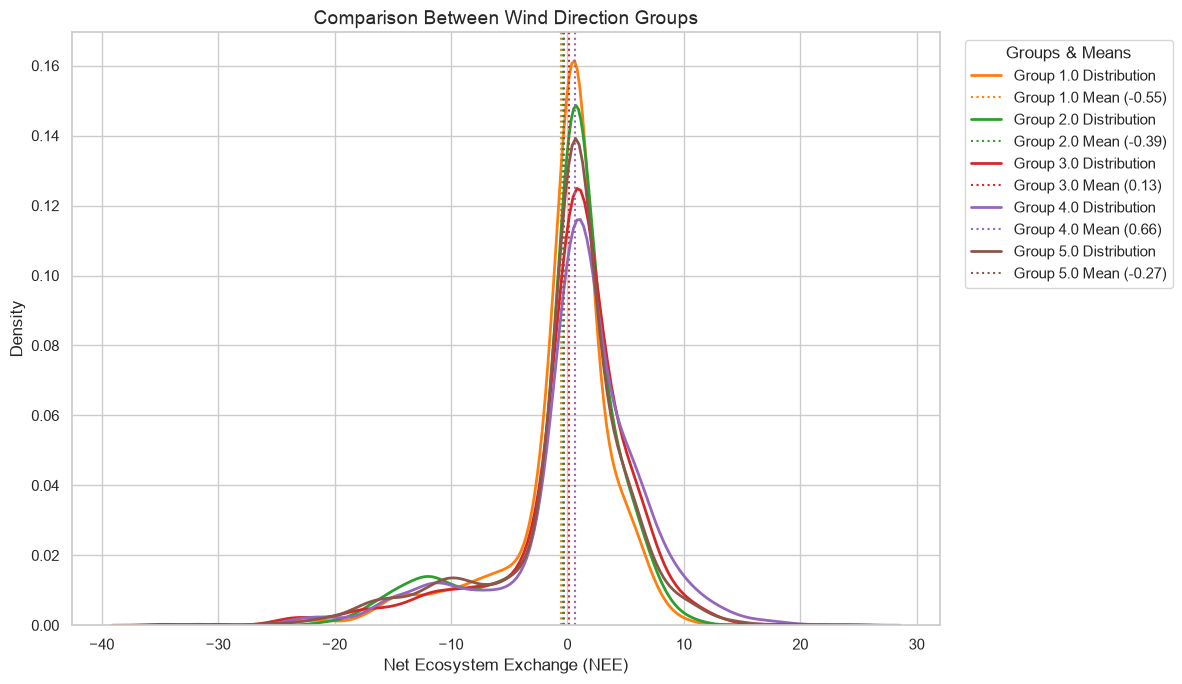

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data labels
df_equal_sample["comparison_group"] = df_equal_sample["wd_category"].apply(
    lambda x: "Lake-ward Wind" if str(x) == "1" else "Other Directions"
)

# 2. Extract Group 1 data and its exact mean
df_group1 = df_equal_sample[df_equal_sample["wd_category"].astype(str) == "1"]
group1_mean = df_group1["NEE_PI_F"].mean()

# 3. Create a single combined figure
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 4. Plot the Group 1 Baseline first (so it sits at the bottom)
sns.kdeplot(
    data=df_group1,
    x="NEE_PI_F",
    fill=True,
    color="#1f77b4",
    alpha=0.2,
    linewidth=2,
    label="Group 1 Distribution",
)

# Add the vertical mean line for Group 1
# plt.axvline(
#     x=group1_mean,
#     color="#1f77b4",
#     linestyle="--",
#     linewidth=2,
#     label=f"Group 1 Mean ({group1_mean:.2f})",
# )

# 5. Define colors for the other groups to keep them distinct
colors = ["#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
other_cats = sorted(
    [
        c
        for c in df_equal_sample["wd_category"].unique()
        if str(c) != "1" and str(c) != "-9999"
    ]
)

# 6. Loop and overlay each individual "Other Group" on top
for cat, color in zip(other_cats, colors):
    df_cat = df_equal_sample[df_equal_sample["wd_category"] == cat]
    cat_mean = df_cat["NEE_PI_F"].mean()

    # Plot the category distribution curve
    sns.kdeplot(
        data=df_cat,
        x="NEE_PI_F",
        fill=False,  # Kept transparent to avoid an unreadable, muddy mess
        color=color,
        linewidth=2,
        label=f"Group {cat} Distribution",
    )

    # Add the vertical mean line for this category
    plt.axvline(
        x=cat_mean,
        color=color,
        linestyle=":",
        linewidth=1.5,
        label=f"Group {cat} Mean ({cat_mean:.2f})",
    )

# 7. Add labels, clean titles, and legend
plt.title(
    "Distribution Across Wind Direction Groups", fontsize=14
)
plt.xlabel("Net Ecosystem Exchange (NEE)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Place the legend cleanly outside or inside the plot
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Groups & Means")

plt.tight_layout()
plt.show()



/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/3936397456.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


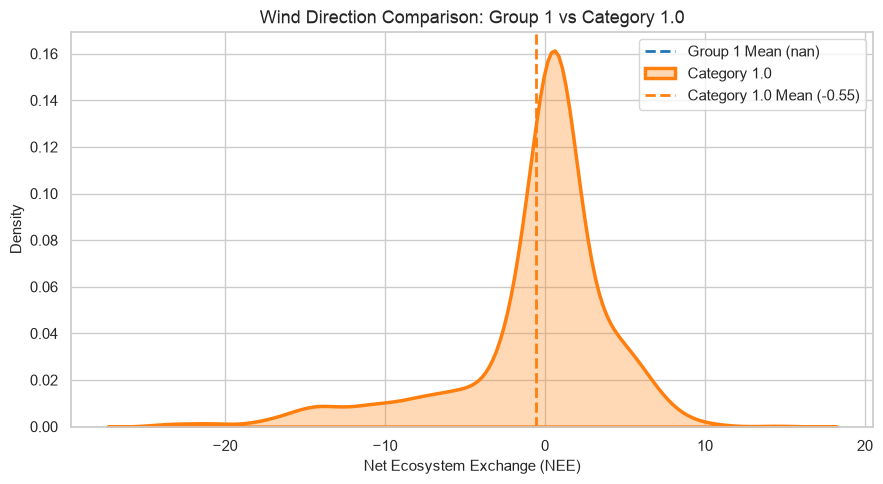

/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/3936397456.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


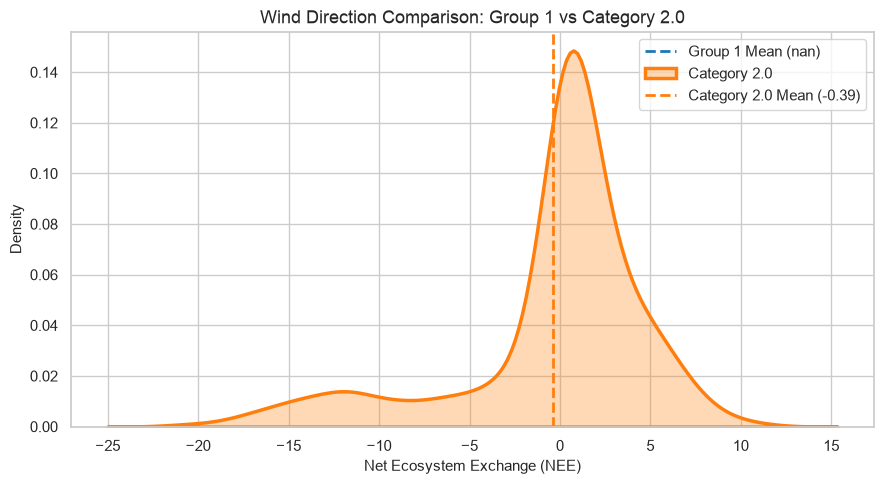

/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/3936397456.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


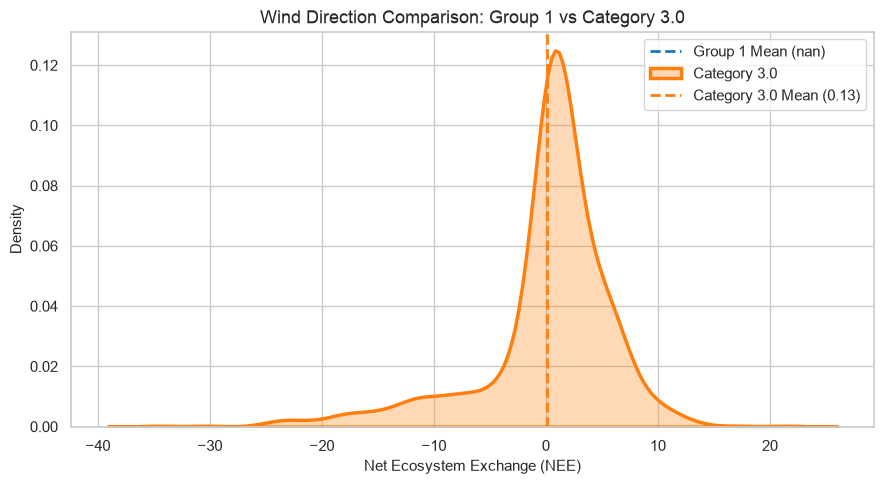

/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/3936397456.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


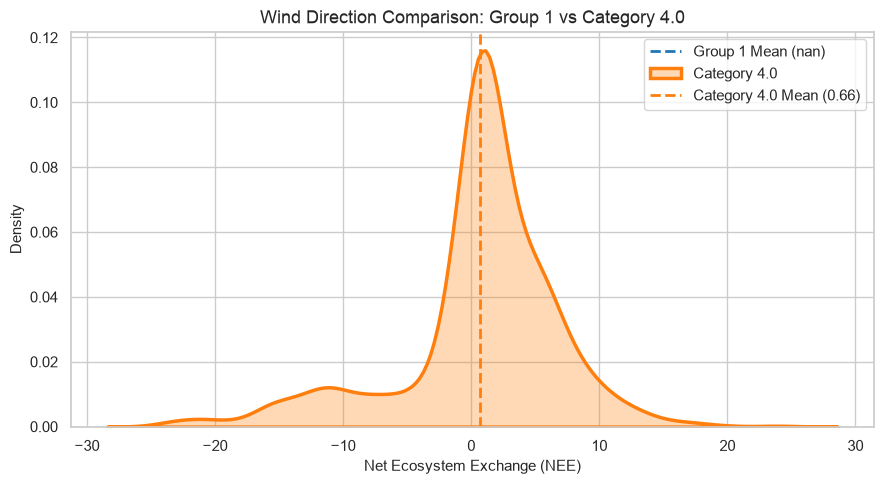

/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/3936397456.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


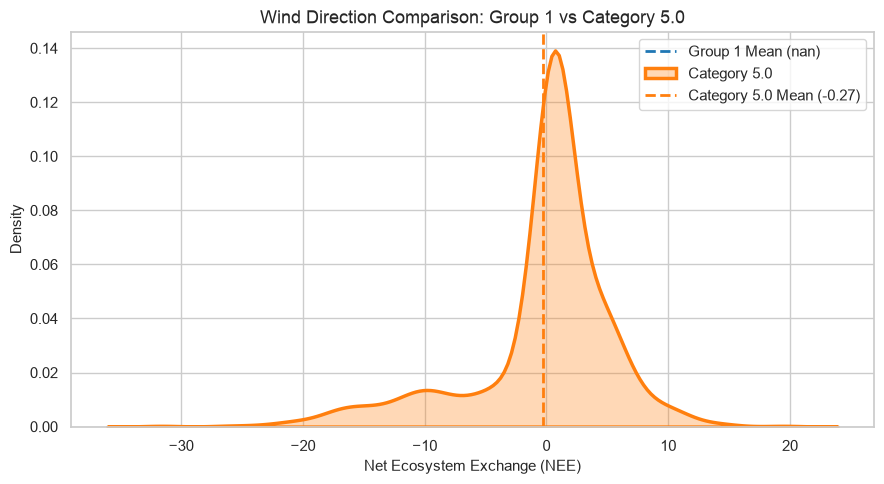

/var/folders/63/gf9f9cv54hz7ngtd7gq168700000gn/T/ipykernel_64738/3936397456.py:28: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


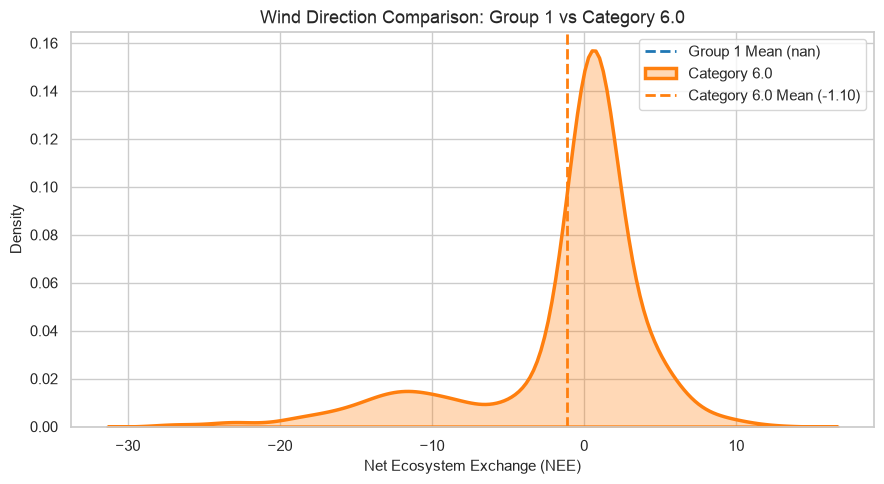

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate Group 1 data and calculate its baseline mean
df_group1 = df_equal_sample[df_equal_sample["wd_category"].astype(str) == "1"]
group1_mean = df_group1["NEE_PI_F"].mean()

# 2. Get a list of the other sorted categories (2 through 6)
other_cats = sorted(
    [
        c
        for c in df_equal_sample["wd_category"].unique()
        if str(c) != "1" and str(c) != "-9999"
    ]
)

# 3. Loop through each category to make its own separate plot
for cat in other_cats:
    # Get data for the specific comparison category
    df_cat = df_equal_sample[df_equal_sample["wd_category"] == cat]
    cat_mean = df_cat["NEE_PI_F"].mean()

    # Create a fresh, clean figure for this specific comparison
    plt.figure(figsize=(9, 5))
    sns.set_theme(style="whitegrid")

    # --- Plot Group 1 Baseline ---
    sns.kdeplot(
        data=df_group1,
        x="NEE_PI_F",
        fill=True,
        color="#1f77b4",
        alpha=0.3,
        linewidth=2.5,
        label="Group 1 (Baseline)",
    )
    plt.axvline(
        x=group1_mean,
        color="#1f77b4",
        linestyle="--",
        linewidth=2,
        label=f"Group 1 Mean ({group1_mean:.2f})",
    )

    # --- Plot the Comparison Category ---
    sns.kdeplot(
        data=df_cat,
        x="NEE_PI_F",
        fill=True,
        color="#ff7f0e",
        alpha=0.3,
        linewidth=2.5,
        label=f"Category {cat}",
    )
    plt.axvline(
        x=cat_mean,
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
        label=f"Category {cat} Mean ({cat_mean:.2f})",
    )

    # --- Customize Labels and Titles ---
    plt.title(f"Wind Direction Comparison: Group 1 vs Category {cat}", fontsize=13)
    plt.xlabel("Net Ecosystem Exchange (NEE)", fontsize=11)
    plt.ylabel("Density", fontsize=11)
    plt.legend(loc="upper right")
    
    # Optional: Keep the X-axis scales identical across all 5 plots for easy comparison
    # plt.xlim(-30, 20) 

    plt.tight_layout()
    
    # Optional: Uncomment the line below if you want to automatically save each plot as an image!
    # plt.savefig(f"NEE_comparison_group_1_vs_{cat}.png", dpi=300)
    
    plt.show()
